## 1.Model Loading ##

In [22]:
import torch
import torch.nn as nn

# (paste UNet class here)

class DoubleConv(nn.Module):
    """(Conv → BN → ReLU) × 2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    Standard U-Net with 4 encoder / decoder levels.
    in_channels : 6 (PRE + POST concatenated)
    out_channels: 1 (binary flood mask logit)
    """
    def __init__(self, in_channels=6, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.pool    = nn.MaxPool2d(2, 2)
        self.decoder = nn.ModuleList()
        self.upconvs = nn.ModuleList()

        # Encoder
        ch = in_channels
        for f in features:
            self.encoder.append(DoubleConv(ch, f))
            ch = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder
        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.decoder.append(DoubleConv(f * 2, f))

        self.final_conv = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for enc in self.encoder:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i, (upconv, dec) in enumerate(zip(self.upconvs, self.decoder)):
            x = upconv(x)
            skip = skips[i]
            # Handle odd dimensions
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = dec(x)

        return self.final_conv(x)  # logits, shape (B, 1, H, W)



IN_CHANNELS = 6

model = UNet(in_channels=IN_CHANNELS, out_channels=1)

model.load_state_dict(torch.load(
    "outputs/prajwal/checkpoints/best_model.pth",
    map_location="cpu"
))

model.eval()

print("Model loaded successfully")

Model loaded successfully


## 2.Dataset Loading ##

In [23]:
import torch
import cv2
import numpy as np

class FloodDataset:
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ✅ correct column names
        pre = cv2.imread(row["pre_path"])
        post = cv2.imread(row["post_path"])
        mask = cv2.imread(row["mask_path"], 0)

        # resize
        pre = cv2.resize(pre, (256,256))
        post = cv2.resize(post, (256,256))
        mask = cv2.resize(mask, (256,256))

        # normalize
        pre = pre / 255.0
        post = post / 255.0
        mask = mask / 255.0

        # 🔥 create 6-channel input
        image = np.concatenate([pre, post], axis=2)

        image = np.transpose(image, (2,0,1))
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)


In [24]:
from torch.utils.data import DataLoader
import pandas as pd

df = pd.read_csv("data/processed/metadata.csv")

dataset = FloodDataset(df)
loader = DataLoader(dataset, batch_size=4)

## 3.Evaluation Metrics ##

In [25]:
def iou_score(preds, targets):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)


def dice_score(preds, targets):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()
    intersection = (preds * targets).sum()
    return (2 * intersection + 1e-6) / (preds.sum() + targets.sum() + 1e-6)


def precision_score(preds, targets):
    preds = (torch.sigmoid(preds) > 0.5).float()
    TP = (preds * targets).sum()
    FP = (preds * (1 - targets)).sum()
    return TP / (TP + FP + 1e-6)


def recall_score(preds, targets):
    preds = (torch.sigmoid(preds) > 0.5).float()
    TP = (preds * targets).sum()
    FN = ((1 - preds) * targets).sum()
    return TP / (TP + FN + 1e-6)

## 4.Evaluation Results ##

In [26]:
total_iou, total_dice = 0, 0
total_precision, total_recall = 0, 0
count = 0

with torch.no_grad():
    for images, masks in loader:
        outputs = model(images)

        total_iou += iou_score(outputs, masks)
        total_dice += dice_score(outputs, masks)
        total_precision += precision_score(outputs, masks)
        total_recall += recall_score(outputs, masks)

        count += 1

print("IoU:", (total_iou / count).item())
print("Dice:", (total_dice / count).item())
print("Precision:", (total_precision / count).item())
print("Recall:", (total_recall / count).item())

IoU: 0.07803206145763397
Dice: 0.1396525651216507
Precision: 0.08589095622301102
Recall: 0.47676217555999756


## 5.Visualization ##

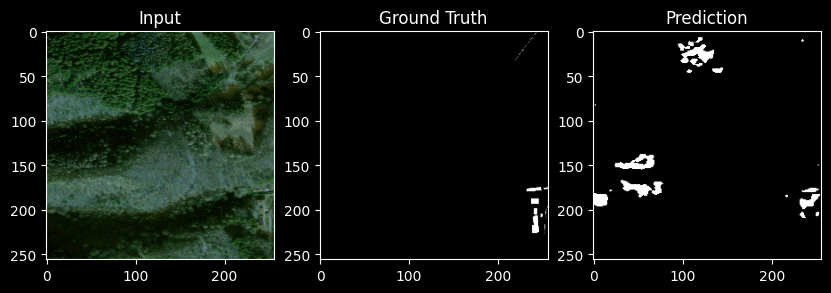

In [27]:
import matplotlib.pyplot as plt

image = images[0]
mask = masks[0]
pred = (torch.sigmoid(outputs[0]) > 0.5).float()

plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.title("Input")
plt.imshow(image[:3].permute(1,2,0))   # show pre-image

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask.squeeze(), cmap="gray")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred.squeeze(), cmap="gray")

plt.show()

In [28]:
import os
os.makedirs("outputs", exist_ok=True)

with open("outputs/results.txt", "w") as f:
    f.write(f"IoU: {(total_iou / count).item()}\n")
    f.write(f"Dice: {(total_dice / count).item()}\n")
    f.write(f"Precision: {(total_precision / count).item()}\n")
    f.write(f"Recall: {(total_recall / count).item()}\n")

## 6.Analysis ##

### Model Performance Analysis

The baseline U-Net model achieves modest performance, with IoU (0.07) and Dice score (0.13), indicating limited overlap between predicted and ground truth flood regions.

The model demonstrates relatively higher recall (0.47), suggesting it is capable of identifying a portion of flood-affected areas. However, the lower precision (0.08) indicates a tendency toward over-segmentation, resulting in false positives.

This behavior is common in baseline segmentation models, where the model prioritizes detection sensitivity over spatial accuracy.

Overall, the results highlight that while the model captures general flood patterns, it lacks fine-grained discrimination, indicating potential for improvement through enhanced training strategies and model refinement.